# FastNBessel numerical validation and API examples

This notebook shows the public package calls used for the numerical
examples in the paper.  It covers products of two through five
spherical Bessel functions, derivatives, bin averages, cylindrical
Bessel functions, and the multidimensional API.  The independent
Simpson routines come from the local `quadrature.py` file and are
not part of the installed package.

Install the repository with `python -m pip install '.[examples]'`
before running the notebook from this `examples/` directory.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import set_workers

from nbessel import BinAverage, NBessel, NBesselND
from quadrature import simpson_1d, simpson_2d_diagonal, simpson_3d_points

plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

## Plotting and test helpers

These small helpers only select output points, construct the smooth
nonseparable multidimensional test input, and format plots.  Every
FastNBessel transform is called explicitly in the sections below.

In [2]:
def fractional_difference(fast, reference):
    fast = np.asarray(fast, dtype=float)
    reference = np.asarray(reference, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        residual = (fast - reference) / reference
    return np.where(reference != 0.0, residual, np.nan)


def indices_in_range(grid, lower, upper, count=None):
    available = np.flatnonzero((grid >= lower) & (grid <= upper))
    if count is None or available.size <= count:
        return available
    return np.unique(
        np.round(np.linspace(available[0], available[-1], count)).astype(int)
    )


def coupled_phi(grids):
    value = np.ones_like(grids[0])
    logarithms = []
    for grid in grids:
        value *= grid**2 * np.exp(-0.5 * grid**2)
        logarithms.append(np.log(grid))
    coupling = np.zeros_like(value)
    for first in range(len(grids)):
        for second in range(first + 1, len(grids)):
            coupling += (logarithms[first] - logarithms[second]) ** 2
    return value * (1.0 + 0.2 * np.exp(-coupling / (2.0 * 0.8**2)))


def transform_scale(axis, *curves):
    values = np.concatenate([np.ravel(curve) for curve in curves])
    values = values[np.isfinite(values)]
    if values.size and np.all(values > 0.0):
        axis.set_yscale("log")
    else:
        nonzero = np.abs(values[values != 0.0])
        threshold = max(np.max(nonzero) * 1.0e-4, np.finfo(float).tiny)
        axis.set_yscale("symlog", linthresh=threshold)
        axis.axhline(0.0, color="0.75", lw=0.6)

## One-dimensional products: $N_B=2,3,4,5$

`NBessel(x, f)` stores one logarithmically sampled input.  The
`orders` and `ratios` arrays passed to `.spherical(...)` contain one
entry per Bessel factor.  The returned array contains the transform
on the logarithmic output grid `r`.

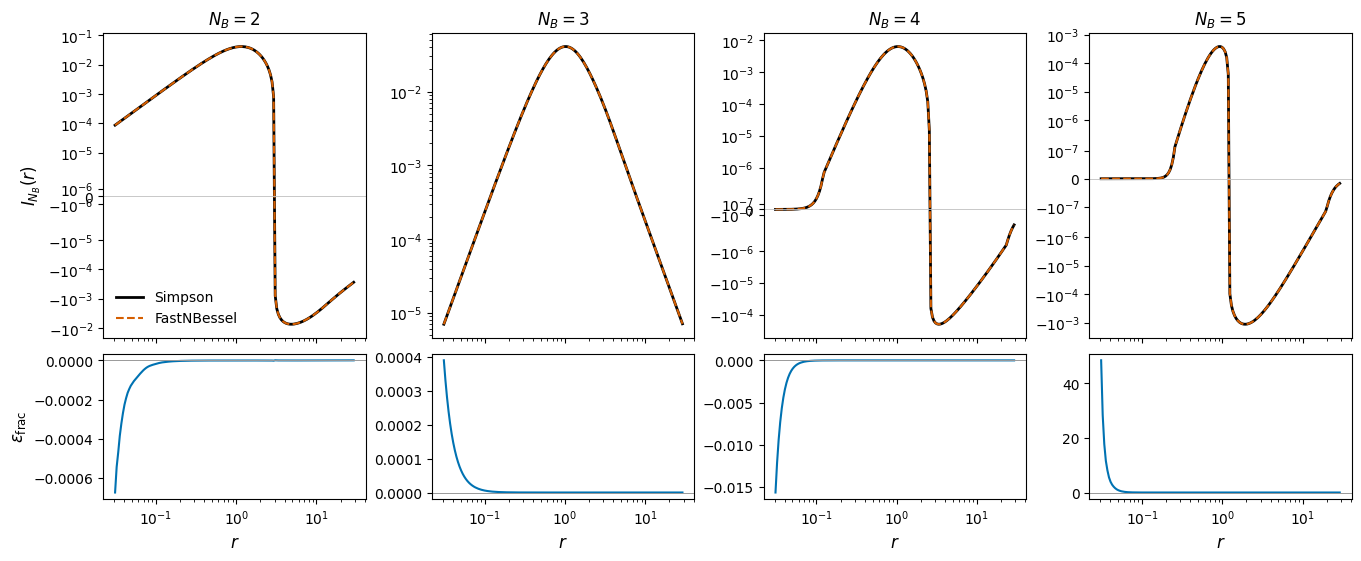

{'N_B=2': {'median |epsilon_frac|': 2.6031285794069713e-07,
  '95th percentile': 0.00017592431482933425},
 'N_B=3': {'median |epsilon_frac|': 6.96915740676401e-08,
  '95th percentile': 0.00011331518041259018},
 'N_B=4': {'median |epsilon_frac|': 1.4710680010536273e-07,
  '95th percentile': 0.0023035259058232027},
 'N_B=5': {'median |epsilon_frac|': 1.0964181806476255e-07,
  '95th percentile': 2.4222028716307134}}

In [3]:
one_dimensional_cases = [
    dict(orders=[0, 2], ratios=[1.0, 0.83], power=2,
         bias=1.0, leg_biases=[0.5, 0.5], mellin_size=16385),
    dict(orders=[0, 1, 2], ratios=[1.0, 0.8, 1.3], power=3,
         bias=1.2, leg_biases=[0.4] * 3, mellin_size=16385),
    dict(orders=[0, 1, 2, 3], ratios=[1.0, 0.73, 1.11, 1.41], power=4,
         bias=1.6, leg_biases=[0.4] * 4, mellin_size=32769),
    dict(orders=[0, 1, 2, 3, 4], ratios=[1.0, 0.69, 0.91, 1.17, 1.43], power=5,
         bias=2.0, leg_biases=[0.4] * 5, mellin_size=32769),
]

x = np.geomspace(1.0e-7, 1.0e3, 512)
dense_x = np.geomspace(1.0e-7, 1.0e3, 32769)
figure, axes = plt.subplots(
    2, 4, figsize=(13.5, 5.5), sharex="col",
    gridspec_kw={"height_ratios": [2.1, 1.0]}, layout="constrained",
)
one_dimensional_metrics = {}

for column, case in enumerate(one_dimensional_cases):
    source = x**case["power"] * np.exp(-0.5 * x**2)

    # This is the complete FastNBessel call for this example.
    r, fast_all = NBessel(x, source).spherical(
        case["orders"],
        case["ratios"],
        bias=case["bias"],
        biases=case["leg_biases"],
        mellin_size=case["mellin_size"],
        y0=1.0e-2,
    )

    index = indices_in_range(r, 3.0e-2, 30.0, 160)
    reference = simpson_1d(
        dense_x,
        dense_x**case["power"] * np.exp(-0.5 * dense_x**2),
        r[index],
        case["orders"],
        case["ratios"],
    )
    fast = fast_all[index]
    residual = fractional_difference(fast, reference)
    finite = np.abs(residual[np.isfinite(residual)])
    one_dimensional_metrics[f"N_B={len(case['orders'])}"] = {
        "median |epsilon_frac|": float(np.median(finite)),
        "95th percentile": float(np.quantile(finite, 0.95)),
    }

    axes[0, column].plot(r[index], reference, color="black", lw=2, label="Simpson")
    axes[0, column].plot(r[index], fast, "--", color="#d55e00", label="FastNBessel")
    axes[1, column].plot(r[index], residual, color="#0072b2")
    axes[0, column].set_title(fr"$N_B={len(case['orders'])}$")
    transform_scale(axes[0, column], reference, fast)
    axes[1, column].axhline(0.0, color="0.6", lw=0.7)
    axes[1, column].set_xlabel(r"$r$")
    axes[0, column].set_xscale("log")
    axes[1, column].set_xscale("log")

axes[0, 0].set_ylabel(r"$I_{N_B}(r)$")
axes[1, 0].set_ylabel(r"$\epsilon_{\mathrm{frac}}$")
axes[0, 0].legend(frameon=False)
plt.show()
one_dimensional_metrics

## Derivatives, bin averages, and cylindrical Bessel functions

Derivative orders and `BinAverage` objects are specified one per
Bessel factor.  Cylindrical transforms use the same object and
numerical controls through `.cylindrical(...)`.

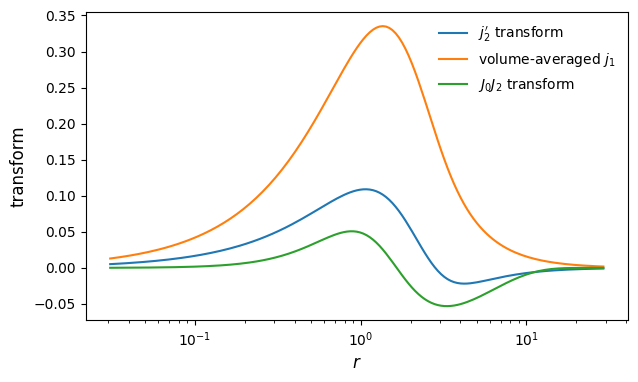

In [4]:
source = x**2 * np.exp(-0.5 * x**2)
calculator = NBessel(x, source)

r, first_derivative = calculator.spherical(
    [2], derivatives=[1], bias=1.01, mellin_size=3, y0=1.0e-2
)
_, volume_average = calculator.spherical(
    [1],
    bins=[BinAverage(0.9, 1.1, dimension=3)],
    bias=1.0,
    mellin_size=3,
    y0=1.0e-2,
)
_, cylindrical = calculator.cylindrical(
    [0, 2],
    [1.0, 0.83],
    bias=1.0,
    biases=[0.5, 0.5],
    mellin_size=16385,
    y0=1.0e-2,
)

visible = (r >= 3.0e-2) & (r <= 30.0)
plt.figure(figsize=(7, 4))
plt.semilogx(r[visible], first_derivative[visible], label=r"$j_2'$ transform")
plt.semilogx(r[visible], volume_average[visible], label="volume-averaged $j_1$")
plt.semilogx(r[visible], cylindrical[visible], label=r"$J_0J_2$ transform")
plt.xlabel(r"$r$")
plt.ylabel("transform")
plt.legend(frameon=False)
plt.show()

## Multidimensional transforms: $(N_B,d)=(2,2)$ and $(4,2)$

`NBesselND` receives one input grid per integration variable.  Each
nested `orders` or `ratios` list describes the Bessel functions
attached to that variable.  The final axes of the sampled source
must match the input grids.

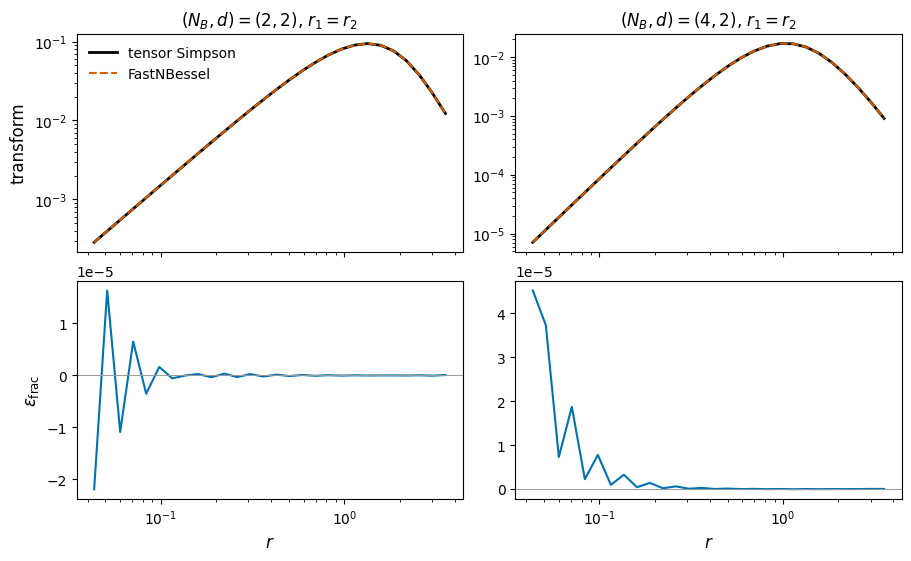

{'$(N_B,d)=(2,2)$': {'median |epsilon_frac|': 1.404538294341492e-07,
  '95th percentile': 1.4425918447675135e-05},
 '$(N_B,d)=(4,2)$': {'median |epsilon_frac|': 1.478166080478286e-07,
  '95th percentile': 3.084236676696066e-05}}

In [5]:
two_dimensional_cases = [
    dict(label=r"$(N_B,d)=(2,2)$", orders=[[0], [2]],
         ratios=[[1.0], [1.0]], leg_biases=[None, None]),
    dict(label=r"$(N_B,d)=(4,2)$", orders=[[0, 1], [0, 2]],
         ratios=[[1.0, 0.8], [1.0, 1.3]],
         leg_biases=[[0.5, 0.5], [0.5, 0.5]]),
]

figure, axes = plt.subplots(2, 2, figsize=(9, 5.5), sharex="col", layout="constrained")
multidimensional_metrics = {}

for column, case in enumerate(two_dimensional_cases):
    x2d = np.geomspace(1.0e-6, 1.0e3, 128)
    mesh = np.meshgrid(x2d, x2d, indexing="ij")
    source = coupled_phi(mesh)

    # One group of Bessel functions is supplied for each input axis.
    (r1, r2), fast_grid = NBesselND([x2d, x2d], source).spherical(
        case["orders"],
        case["ratios"],
        biases=[1.0, 1.0],
        leg_biases=case["leg_biases"],
        mellin_size=8193,
        y0=[1.0e-2, 1.0e-2],
    )

    index = indices_in_range(r1, 4.0e-2, 4.0)
    dense_x2d = np.geomspace(1.0e-6, 1.0e3, 501)
    dense_mesh = np.meshgrid(dense_x2d, dense_x2d, indexing="ij")
    reference = simpson_2d_diagonal(
        dense_x2d,
        dense_x2d,
        coupled_phi(dense_mesh),
        r1[index],
        r2[index],
        case["orders"],
        case["ratios"],
    )
    fast = fast_grid[index, index]
    residual = fractional_difference(fast, reference)
    finite = np.abs(residual[np.isfinite(residual)])
    multidimensional_metrics[case["label"]] = {
        "median |epsilon_frac|": float(np.median(finite)),
        "95th percentile": float(np.quantile(finite, 0.95)),
    }

    axes[0, column].plot(r1[index], reference, color="black", lw=2, label="tensor Simpson")
    axes[0, column].plot(r1[index], fast, "--", color="#d55e00", label="FastNBessel")
    axes[1, column].plot(r1[index], residual, color="#0072b2")
    axes[0, column].set_title(case["label"] + r", $r_1=r_2$")
    transform_scale(axes[0, column], reference, fast)
    axes[1, column].axhline(0.0, color="0.6", lw=0.7)
    axes[0, column].set_xscale("log")
    axes[1, column].set_xscale("log")
    axes[1, column].set_xlabel(r"$r$")

axes[0, 0].set_ylabel("transform")
axes[1, 0].set_ylabel(r"$\epsilon_{\mathrm{frac}}$")
axes[0, 0].legend(frameon=False)
plt.show()
multidimensional_metrics

## Six Bessel functions in three dimensions: $(N_B,d)=(6,3)$

This is the largest validation example in the paper.  Two Bessel
functions are attached to each of the three integration variables.
Only a small set of diagonal output points is evaluated by direct
tensor-product quadrature.

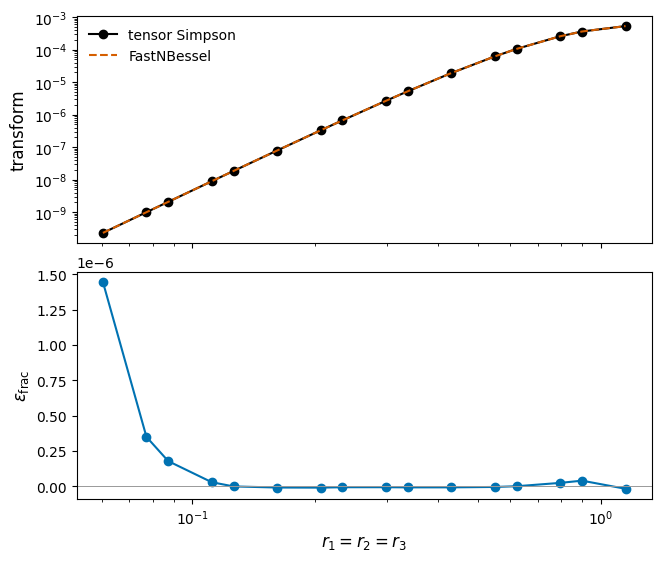

{'median |epsilon_frac|': 8.29725359146967e-09,
 '95th percentile': 6.242701308313268e-07}

In [6]:
x3d = np.geomspace(1.0e-7, 30.0, 160)
mesh3d = np.meshgrid(x3d, x3d, x3d, indexing="ij")
source3d = coupled_phi(mesh3d)
orders3d = [[0, 1], [1, 2], [0, 2]]
ratios3d = [[1.0, 0.8], [1.0, 1.2], [1.0, 0.9]]

(r1, r2, r3), fast_grid3d = NBesselND([x3d] * 3, source3d).spherical(
    orders3d,
    ratios3d,
    biases=[0.5] * 3,
    leg_biases=[[0.25, 0.25]] * 3,
    mellin_size=32769,
    oversampling=4,
    y0=[2.0e-2] * 3,
)

index3d = indices_in_range(r1, 6.0e-2, 1.2, 16)
points3d = np.column_stack([axis[index3d] for axis in (r1, r2, r3)])
dense_x3d = np.geomspace(1.0e-7, 30.0, 193)
dense_mesh3d = np.meshgrid(dense_x3d, dense_x3d, dense_x3d, indexing="ij")
reference3d = simpson_3d_points(
    [dense_x3d] * 3,
    coupled_phi(dense_mesh3d),
    points3d,
    orders3d,
    ratios3d,
)
fast3d = fast_grid3d[index3d, index3d, index3d]
residual3d = fractional_difference(fast3d, reference3d)

figure, axes = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True, layout="constrained")
axes[0].plot(points3d[:, 0], reference3d, "o-", color="black", label="tensor Simpson")
axes[0].plot(points3d[:, 0], fast3d, "--", color="#d55e00", label="FastNBessel")
axes[1].plot(points3d[:, 0], residual3d, "o-", color="#0072b2")
transform_scale(axes[0], reference3d, fast3d)
axes[0].legend(frameon=False)
axes[0].set_ylabel("transform")
axes[1].set_ylabel(r"$\epsilon_{\mathrm{frac}}$")
axes[1].set_xlabel(r"$r_1=r_2=r_3$")
axes[1].set_xscale("log")
axes[1].axhline(0.0, color="0.6", lw=0.7)
plt.show()

finite3d = np.abs(residual3d[np.isfinite(residual3d)])
{
    "median |epsilon_frac|": float(np.median(finite3d)),
    "95th percentile": float(np.quantile(finite3d, 0.95)),
}

## Compact timing and Mellin-convergence example

The publication timing figure is produced by
`run_numerical_validation.py`, which also refines the quadrature
until its change is below $10^{-5}$.  Here the relevant package
calls are shown directly: the left panel varies the outer FFTLog
size, and the right panel varies the internal Mellin grid.

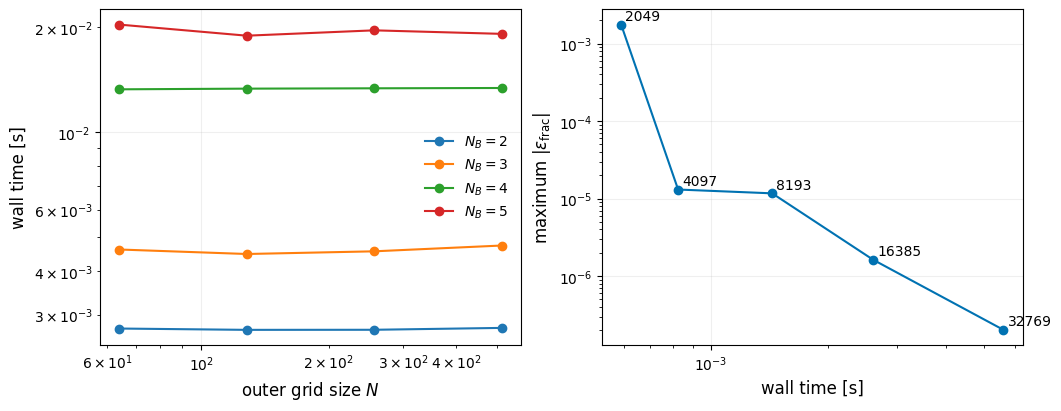

In [7]:
def median_time(function, repetitions=3):
    function()
    samples = []
    for _ in range(repetitions):
        start = perf_counter()
        function()
        samples.append(perf_counter() - start)
    return float(np.median(samples))


outer_sizes = np.array([64, 128, 256, 512])
timing_results = {}
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4), layout="constrained")

with set_workers(1):
    for case in one_dimensional_cases:
        elapsed = []
        for size in outer_sizes:
            timing_x = np.geomspace(1.0e-7, 1.0e3, int(size))
            timing_source = timing_x**case["power"] * np.exp(-0.5 * timing_x**2)

            def evaluate():
                return NBessel(timing_x, timing_source).spherical(
                    case["orders"],
                    case["ratios"],
                    bias=case["bias"],
                    biases=case["leg_biases"],
                    mellin_size=case["mellin_size"],
                    y0=1.0e-2,
                )

            elapsed.append(median_time(evaluate, repetitions=2))
        timing_results[f"N_B={len(case['orders'])}"] = elapsed
        axes[0].plot(outer_sizes, elapsed, "o-", label=fr"$N_B={len(case['orders'])}$")

    reference_case = one_dimensional_cases[0]
    reference_x = np.geomspace(1.0e-7, 1.0e3, 512)
    reference_source = reference_x**2 * np.exp(-0.5 * reference_x**2)
    reference_r, _ = NBessel(reference_x, reference_source).spherical(
        reference_case["orders"], reference_case["ratios"],
        bias=reference_case["bias"], biases=reference_case["leg_biases"],
        mellin_size=32769, y0=1.0e-2,
    )
    check = np.array([70, 110, 150, 190])
    reference_values = simpson_1d(
        dense_x, dense_x**2 * np.exp(-0.5 * dense_x**2),
        reference_r[check], reference_case["orders"], reference_case["ratios"],
    )
    mellin_sizes = np.array([2049, 4097, 8193, 16385, 32769])
    errors = []
    mellin_times = []
    for mellin_size in mellin_sizes:
        def evaluate_mellin():
            return NBessel(reference_x, reference_source).spherical(
                reference_case["orders"], reference_case["ratios"],
                bias=reference_case["bias"], biases=reference_case["leg_biases"],
                mellin_size=int(mellin_size), y0=1.0e-2,
            )

        _, values = evaluate_mellin()
        errors.append(np.nanmax(np.abs(fractional_difference(values[check], reference_values))))
        mellin_times.append(median_time(evaluate_mellin, repetitions=2))

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("outer grid size $N$")
axes[0].set_ylabel("wall time [s]")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.2)
axes[1].loglog(mellin_times, errors, "o-", color="#0072b2")
for x_time, error, size in zip(mellin_times, errors, mellin_sizes):
    axes[1].annotate(str(size), (x_time, error), xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("wall time [s]")
axes[1].set_ylabel(r"maximum $|\epsilon_{\mathrm{frac}}|$")
axes[1].grid(alpha=0.2)
plt.show()